# TP06 : Réseaux de Neurones 1 et Révision Sklearn
# 📘 VERSION ENSEIGNANT — Corrigé commenté

> **Usage réservé à l'enseignant.** Ce notebook contient les solutions complètes avec commentaires pédagogiques.  
> Les cellules `# 🏫 NOTE ENSEIGNANT` sont destinées à guider les discussions en séance.


### Modalités de rendu

1. Chaque étudiant doit rendre un travail individuel.
2. Renommez ce fichier selon la convention : `TP06_Nom_Prenom.ipynb`.
3. Le rendu s'effectuera via le lien de dépôt communiqué par votre enseignant.
4. Assurez-vous que votre code s'exécute sans erreur (Menu : Kernel > Restart & Run All).

### Objectifs de la séance

Ce TP a pour objectif d'apprendre à créer des réseaux de neurones avec sklearn, ici pour résoudre un problème de régression, ainsi que de revoir les routines de sklearn pour être prêt pour le projet.

### Documentation utile

- [Scikit-Learn MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html#sklearn.neural_network.MLPRegressor)
- [sklearn Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
- [sklearn GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

## Organisation du TP

Ce TP contient 3 parties :

1. **Régression par Réseaux de Neurones Artificiels**
2. **Optimisation des hyperparamètres**
3. **Récapitulatif des routines de sklearn**

## Imports globaux

Exécutez cette cellule avant de commencer.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error


import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## Chargement du jeu de données Combined Cycle Power Plant

CCPP contient 9568 lignes de données collectés d'une centrale électrique sur une période de 6 ans (2006-2011), lorsqu'elle fonctionnait encore à plein régime.  

In [2]:
# Chargement CCPP — cette cellule est fournie, exécutez-la simplement
print("Chargement des données...")
ccpp_df = pd.read_csv(".\CCPP\Power_Plant_Data.csv")

Chargement des données...


Visualisez le jeu de donnée grâce à l'attribut `info` et la méthode `head()`.

Vérifiez également qu'il n'y a pas de données manquantes dans votre jeu de données.

In [3]:
print(ccpp_df.info)
print(ccpp_df.head())

ccpp_df.isna().values.any()

<bound method DataFrame.info of          AT      V       AP     RH      PE
0     14.96  41.76  1024.07  73.17  463.26
1     25.18  62.96  1020.04  59.08  444.37
2      5.11  39.40  1012.16  92.14  488.56
3     20.86  57.32  1010.24  76.64  446.48
4     10.82  37.50  1009.23  96.62  473.90
...     ...    ...      ...    ...     ...
9563  16.65  49.69  1014.01  91.00  460.03
9564  13.19  39.18  1023.67  66.78  469.62
9565  31.32  74.33  1012.92  36.48  429.57
9566  24.48  69.45  1013.86  62.39  435.74
9567  21.60  62.52  1017.23  67.87  453.28

[9568 rows x 5 columns]>
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90


False

Ce jeu de données possède 5 attributs :
- La Température (AT) en Celcius
- L'Exhaust Vacuum (V) en millimètre de mercure (unité de pression)
- La Pression Ambiante (AP) en millibar
- L'Humidité Relative (RH) en pourcentage
- La Production d'énergie électrique nette horaire (PE) en MegaWatt

L'objectif dans la partie 1 va être de créer un réseau de neurones capable de prédire la production d'énergie a partie des 4 autres caractéristiques.

---

# Partie 1 — Régression par Réseaux de Neurones Artificiels

## Rappel théorique

/!\ A compléter /!\

## Étape 1 — Standardisation

Avant tout travail sur un algorithme d'apprentissage, il est crucial de **centrer** les données pour éviter de donner artificiellement trop d'importance à certains attributs.

In [4]:
# Séparation train/test avec un ratio de 80%/20%

X=ccpp_df[['AT','V','AP','RH']]
y=ccpp_df[['PE']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler1 = StandardScaler()
X_train_sc = scaler1.fit_transform(X_train)   # On fit notre scaler et on transforme ces donnée
X_test_sc  = scaler1.transform(X_test)   # transform seulement — pas de fit !

# On créer un scaler différent pour les données que l'on cherche à prédire.
# On a envie de centrer nos données pour notre modèle, 
# mais on a besoin de pouvoir les dé-transformer après pour avoir les vrais valeurs.
scaler2 = StandardScaler()
y_train_sc = scaler2.fit_transform(y_train)    # On fit notre scaler et on transforme ces donnée
y_test_sc  = scaler2.transform(y_test)   # transform seulement — pas de fit !


## Étape 2 — Créer un premier réseau de neurones

Sklearn permet de créer des Perceptrons Multicouches pour de la classification (**MLPClassifier**) et de la régression (**MLPRegressor**), celui qui nous intéresse pour ce TP.

On souhaite que ce réseau de neurones ait :
- 2 couches de neurones cachés comprenant 10 neurones chacuns,
- la fonction d'activation de ces neurones soit la fonction "ReLU",
- la fonction d'optimisation des poids soit celle de la descente de gradient stochastique.

On ne se préoccupe pas pour l'instant de savoir si ces hyperparamètres sont optimaux, on cherche juste à se familiariser avec le modèle.

In [5]:
model = MLPRegressor(hidden_layer_sizes=[10,10],activation="relu",solver="sgd",random_state=42)

Entrainons maintenant notre modèle.

Attention, notre problème étant un problème de régression, nous ne pouvons évaluer la performance notre modèle avec des métriques faîtes pour évaluer des modèles de classification (comme `accuracy_score()`).
Plusieurs métriques existent pour évaluer des modèles de régression. Nous utiliserons ici `mean_square_error()`.

In [6]:
model.fit(X_train_sc,y_train_sc)
y_pred_sc=model.predict(X_test_sc)

print( "Le MSE des données scalées prédites par notre modèle est de :",
      mean_squared_error(y_true=y_test_sc,y_pred=y_pred_sc))

# On veut regarder le résultat avec nos données prédites unscale.
# On doit donc faire la transformée inverse de nos données prédites
y_pred_unsc=scaler2.inverse_transform(np.reshape(y_pred_sc,(-1,1)))

print( "Le MSE des données scalées prédites par notre modèle est de :",
      mean_squared_error(y_true=y_test,y_pred=y_pred_unsc))



Le MSE des données scalées prédites par notre modèle est de : 0.06599894643114444
Le MSE des données scalées prédites par notre modèle est de : 19.240582504374878


On voit que la valeur du MSE dépend de l'échelle des valeurs évaluées. Dans une approche de comparaisons de performances de modèles, il est préférable de faire le MSE sur des valeurs centrées (même s'il faut quand même garder un moyen de retransformer nos valeurs centrées pour avoir les vraies valeurs prédites.)

Visualisons quelques résultats prédits :

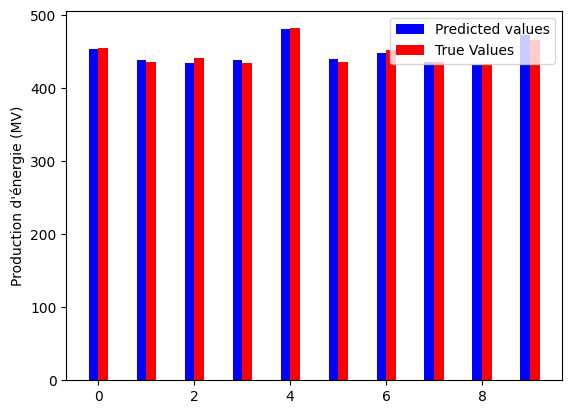

In [7]:
r=np.array(range(10))

ax=plt.subplot(111)
ax.bar(r-0.1,np.concatenate(y_pred_unsc[0:10]),color='blue',label="Predicted values",width=0.2)
ax.bar(r+0.1,np.concatenate(np.array(y_test[0:10])),color='red', label="True Values",width=0.2)

plt.ylabel("Production d'énergie (MV)")
plt.legend()

plt.show()

---

# Partie 2 — Optimisation des hyperparamètres par Validation croisée

## Rappel théorique

/!\ A compléter /!\

Quand on cherche à optimiser les hyperparamètres de notre modèle, même en séparant notre jeu de données en entrainement/test, il y a un risque de faire surapprendre (overfit) les résultats du jeu de données **test**. Une solution simple pour minimiser ce problème est la **validation croisée**.

Le principe est le suivant : après avoir séparé notre jeu de données en 2 (entrainement/test), on prend les données d'entrainement, et on les re-séparent en $n$ plusieurs sous-jeux de données de taille égales. La validation croisée va consister à, pour chaque combinaison d'hyperparamètres à tester, entrainer notre modèle sur chaque combinaison de $n-1$ jeu de données, et le tester sur celui restant.

La performance du modèle pour un ensemble d'hyperparamètres donné est alors la moyenne des performances de chaque combinaison de sous-jeu de données.

Pour nous aider à comprendre, essayons d'implémenter cela.
Nous souhaitons tester les hyperparamètres suivant pour notre modèle :
- 1, 2 ou 3 couches cachées
- les couches cachées contiennent toute 10, 20 ou 30 neurones
- la méthode de descente de gradient est soit "sgd", soit "adam".

In [8]:
num_layers=[1,2,3]
layer_size=[10,20,30]
solver=["sgd","adam"]

Nous souhaitons séparer notre jeu de données d'entrainement en 5 grâce à la `KFold()`:

In [9]:
kf=KFold(n_splits=5,shuffle=True,random_state=42)

#On visualise les sous-jeux de données
for i, (train_index, test_index) in enumerate(kf.split(X_train_sc,y_train_sc)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[   1    2    3 ... 7650 7651 7653]
  Test:  index=[   0    8   14 ... 7641 7643 7652]
Fold 1:
  Train: index=[   0    1    2 ... 7651 7652 7653]
  Test:  index=[  12   15   26 ... 7631 7646 7647]
Fold 2:
  Train: index=[   0    1    2 ... 7647 7650 7652]
  Test:  index=[   6    7   18 ... 7649 7651 7653]
Fold 3:
  Train: index=[   0    3    4 ... 7651 7652 7653]
  Test:  index=[   1    2   10 ... 7639 7644 7650]
Fold 4:
  Train: index=[   0    1    2 ... 7651 7652 7653]
  Test:  index=[   3    4    5 ... 7636 7638 7642]


Maintenant, on souhaite tester notre modèle pour chaque hyperparamètre. 

In [10]:
for nl in num_layers: # Pour chaque quantité de couches cachées
    for sl in layer_size: # Pour chaque taille de couche
        for s in solver: # Pour chaque solver
            hls=np.ones(nl,dtype=np.int64)*sl
            model2 = MLPRegressor(hidden_layer_sizes=hls,activation="relu",solver=s,random_state=42)
            score=[]
            for i, (train_index, test_index) in enumerate(kf.split(X_train_sc,y_train_sc)):
                model2.fit(X_train_sc[train_index],y_train_sc[train_index])
                y_pred=model2.predict(X_train_sc[test_index])
                score.append(mean_squared_error(y_true=y_train_sc[test_index],y_pred=y_pred))
            print(
                "num_layer : ",nl,
                "\nlayer size : ",sl,
                "\nsolver : ",s,
                "score = ", np.mean(score)
            )
            

num_layer :  1 
layer size :  10 
solver :  sgd score =  0.06852203030520315
num_layer :  1 
layer size :  10 
solver :  adam score =  0.06472009943952538
num_layer :  1 
layer size :  20 
solver :  sgd score =  0.06768126328048227
num_layer :  1 
layer size :  20 
solver :  adam score =  0.06291419892434102
num_layer :  1 
layer size :  30 
solver :  sgd score =  0.06809387121203767
num_layer :  1 
layer size :  30 
solver :  adam score =  0.061964836515033636
num_layer :  2 
layer size :  10 
solver :  sgd score =  0.06889170992402911
num_layer :  2 
layer size :  10 
solver :  adam score =  0.06162172899478926
num_layer :  2 
layer size :  20 
solver :  sgd score =  0.06703119810829844
num_layer :  2 
layer size :  20 
solver :  adam score =  0.05926193204033875
num_layer :  2 
layer size :  30 
solver :  sgd score =  0.06593369466321274
num_layer :  2 
layer size :  30 
solver :  adam score =  0.056326967967279526
num_layer :  3 
layer size :  10 
solver :  sgd score =  0.069030266

Ce travail peut être assez fastidieux. Heureusement, il existe des fonctions déja implémentées dans *sklearn* qui vont nous permettre de grandement simplifier l'écriture du code.

La fonction `GridSearchCV()` permet d'effectuer les tests de tout les hyperparamètres voulu pour n'importe quel modèle, et d'obtenir les scores calculés pour chaque combinaison. On veut séparer notre jeu d'entrainement en 5 et que la fonction de score soit **mean_square_error**.

In [11]:
mlpr=MLPRegressor()

hyperparam={
    'hidden_layer_sizes':[[10],[20],[30],[10,10],[20,20],[30,30],[10,10,10],[20,20,20],[30,30,30]],
    'solver':["adam","sgd"]
}

gscv=GridSearchCV(mlpr,hyperparam,cv=5,scoring="neg_mean_squared_error")

gscv.fit(X_train_sc,y_train_sc)

print(gscv.cv_results_)

{'mean_fit_time': array([0.30692639, 0.30768247, 0.2652431 , 0.26673422, 0.28113756,
       0.27968602, 0.55412593, 0.56197777, 0.47746196, 0.54162698,
       0.64612279, 0.48705125, 0.57926841, 0.55988913, 0.79529815,
       0.6632185 , 1.31143122, 0.7038084 ]), 'std_fit_time': array([0.05789285, 0.04463038, 0.06013626, 0.0421175 , 0.05413299,
       0.02834785, 0.15046569, 0.13652292, 0.05749763, 0.15940254,
       0.15545868, 0.06177212, 0.07288112, 0.11504494, 0.14385042,
       0.08091735, 0.34344896, 0.12375069]), 'mean_score_time': array([0.00066276, 0.00057354, 0.00120378, 0.00049973, 0.00080652,
       0.00102839, 0.00092287, 0.00071845, 0.00130453, 0.00099711,
       0.00127835, 0.00105734, 0.0010035 , 0.00080361, 0.00100431,
       0.00107784, 0.00100589, 0.00130968]), 'std_score_time': array([5.51963190e-04, 5.42450810e-04, 2.44508779e-04, 6.32070433e-04,
       4.03327867e-04, 5.52091332e-04, 4.93163478e-04, 6.10687856e-04,
       3.98747774e-04, 5.44331356e-04, 3.89771500

In [12]:
cv_res=np.dstack((np.array(gscv.cv_results_["params"]),
                  gscv.cv_results_["mean_test_score"],
                  gscv.cv_results_["rank_test_score"]))[0]

# Hyperparamètre ordonnées du plus au moins performant
print(cv_res[cv_res[:,2].argsort()])

print("Le meilleur set d'hyperparamètres parmis ceux testés est : ",
      cv_res[cv_res[:,2].argsort()][0][0])

[[{'hidden_layer_sizes': [30, 30, 30], 'solver': 'adam'}
  -0.05472375789919622 1]
 [{'hidden_layer_sizes': [30, 30], 'solver': 'adam'} -0.05683185906768425
  2]
 [{'hidden_layer_sizes': [20, 20, 20], 'solver': 'adam'}
  -0.05686079996168257 3]
 [{'hidden_layer_sizes': [20, 20], 'solver': 'adam'} -0.05904878289509209
  4]
 [{'hidden_layer_sizes': [10, 10, 10], 'solver': 'adam'}
  -0.060560453462584374 5]
 [{'hidden_layer_sizes': [30], 'solver': 'adam'} -0.061980671557812485 6]
 [{'hidden_layer_sizes': [10, 10], 'solver': 'adam'} -0.06203713075127021
  7]
 [{'hidden_layer_sizes': [20], 'solver': 'adam'} -0.062075087872087556 8]
 [{'hidden_layer_sizes': [30, 30, 30], 'solver': 'sgd'}
  -0.06455225715654772 9]
 [{'hidden_layer_sizes': [20, 20, 20], 'solver': 'sgd'}
  -0.06478421229484724 10]
 [{'hidden_layer_sizes': [10], 'solver': 'adam'} -0.06480528338357125 11]
 [{'hidden_layer_sizes': [30], 'solver': 'sgd'} -0.06636340651238794 12]
 [{'hidden_layer_sizes': [30, 30], 'solver': 'sgd'} -

### 📝 Observations

*Quels choix d'hyperparamètres semblent améliorer le plus notre modèle ?*


# Partie 3 — Récapitulatif des routines de sklearn

Maintenant, nous allons révoir une dernière fois tout ce qui a été fait.
- On doit utiliser **train_test_split** pour séparer notre jeu de données en 2, des données d'entrainement et des données de test.
- Ensuite, on va utiliser une **Pipeline()** pour effectuer des transformations successives de nos données jusqu'à entrainer notre modèle (ici, on mettra dans la pipeline **StandardScaler()** et **MLPRegressor()**).
- Nous allons faire une validation croisée pour trouver les meilleurs hyperparamètres à choisir.
- Enfin, nous entraineront notre modèle optimisé sur les données d'entrainement, et le testeront sur des données test.

N'hésitez pas à essayer d'autres hyperparamètres que ceux proposés pour essayer d'avoir d'encore meilleurs résultats !

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlpreg', MLPRegressor(random_state=42))
])

# Attention ! Quand on code nos hyperparamètres à optimiser en passant par une Pipeline, 
# il ne faut pas oublier de formater le nom
hyperparam = {
    'mlpreg__hidden_layer_sizes':[[10],[20],[30],[10,10],[20,20],[30,30],[10,10,10],[20,20,20],[30,30,30]],
    'mlpreg__solver':["adam","sgd"]
}

gscv=GridSearchCV(pipeline,hyperparam,cv=5,scoring="neg_mean_squared_error")

gscv.fit(X_train,y_train)

cv_opti=np.dstack((np.array(gscv.cv_results_["params"]),gscv.cv_results_["mean_test_score"],gscv.cv_results_["rank_test_score"]))[0]
#On garde les hyperparamètres donnant les meilleurs performances
param_opti=cv_opti[cv_opti[:,2].argsort()][0][0]

final_model = Pipeline([
    ('scaler',StandardScaler()),
    (('mlpreg', MLPRegressor(hidden_layer_sizes=param_opti['mlpreg__hidden_layer_sizes'],solver=param_opti['mlpreg__solver'],random_state=42)))
])

final_model.fit(X_train,y_train)

y_pred=final_model.predict(X_test)
print(mean_squared_error(y_true=y_test,y_pred=y_pred))


18.10657838197996
